In [66]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, SimpleRNN, LSTM, Dropout
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
from tensorflow.keras.optimizers import Adam
import warnings
warnings.filterwarnings('ignore')

## Датасет

**Значения**
1) LocalTime - местное время для данного метерологического наблюдения (дата и время)
2) T -  температура воздуха в цельсиях
3) Po - давление на уровне станции (мм рт. столба)
4) P - давлениена уровне моря (мм рт. столба)
5) Pa - атмосферное давление для широты (мм рт. столба)
6) U - влажность воздуха в %
7) DD - наличие и отсутствие ветра (Штиль и ветер)

In [2]:
df = pd.read_excel('weather.xlsx')

In [3]:
df.head()

,LocalTime,T,Po,P,Pa,U,DD
0,2020-10-19 11:00:00,8,761.2,762.5,NaN,83.0,Ветер
1,2020-10-19 08:00:00,2025-03-05 00:00:00,760.0,761.3,NaN,90.0,Ветер
2,2020-10-19 05:00:00,2025-01-03 00:00:00,759.2,760.6,NaN,94.0,Ветер
3,2020-10-19 02:00:00,2025-09-02 00:00:00,758.2,759.6,NaN,90.0,Ветер
4,2020-10-18 23:00:00,3,757.2,758.5,NaN,91.0,Ветер


In [4]:
df.dtypes

LocalTime    datetime64[ns]
T                    object
Po                  float64
P                   float64
Pa                   object
U                   float64
DD                   object
dtype: object

In [5]:
temp_series = pd.to_numeric(df['T'], errors='coerce')
temp_mean = temp_series.mean()
df['T'] = temp_series.fillna(temp_mean)

In [6]:
df['Pa'] = pd.to_numeric(df['Pa'], errors='coerce')
df['Pa'] = df['Pa'].fillna(df['Pa'].mean())

In [7]:
df['Po'] = pd.to_numeric(df['Po'], errors='coerce').fillna(df['Po'].mean())
df['P'] = pd.to_numeric(df['P'], errors='coerce').fillna(df['P'].mean())
df['U'] = pd.to_numeric(df['U'], errors='coerce').fillna(df['U'].mean())

In [8]:
df['LocalTime'] = pd.to_datetime(df['LocalTime'])
df['hour'] = df['LocalTime'].dt.hour
df['day_of_week'] = df['LocalTime'].dt.dayofweek
df['day_of_year'] = df['LocalTime'].dt.dayofyear
df['month'] = df['LocalTime'].dt.month
df['year'] = df['LocalTime'].dt.year

In [ ]:
df['LocalTime'] = pd.to_datetime(df['LocalTime'], errors='coerce')

df['T'] = pd.to_numeric(df['T'], errors='coerce')
df = df.dropna(subset=['T']) 
df['T'] = df['T'].clip(-50, 50) 
df['T'] = df['T'].fillna(df['T'].median())

df['Pa'] = pd.to_numeric(df['Pa'], errors='coerce').fillna(0)

df['DD'] = df['DD'].map({'Ветер': 1, 'Штиль': 0}).fillna(0)

df['Po'] = pd.to_numeric(df['Po'], errors='coerce').fillna(df['Po'].mean())
df['P'] = pd.to_numeric(df['P'], errors='coerce').fillna(df['P'].mean())
df['U'] = pd.to_numeric(df['U'], errors='coerce').fillna(df['U'].mean())

df['hour'] = df['LocalTime'].dt.hour
df['day_of_week'] = df['LocalTime'].dt.dayofweek
df['month'] = df['LocalTime'].dt.month

features = ['T', 'Po', 'P', 'Pa', 'U', 'DD', 'hour', 'day_of_week', 'month']
df = df[features].dropna()

print(f"Подготовлено {len(df)} строк данных")

Подготовлено 26269 строк данных


In [71]:
df.head()

,T,Po,P,Pa,U,DD,hour,day_of_week,month
0,1.996792,772.6,774.6,-0.180034,94.0,0.0,2,5,10
1,1.996792,772.4,774.4,-0.180034,94.0,0.0,5,5,10
2,1.996792,772.9,774.9,-0.180034,93.0,0.0,8,5,10
3,1.996792,773.3,775.3,-0.180034,68.0,0.0,11,5,10
4,9.000000,773.2,775.2,-0.180034,64.0,0.0,14,5,10


In [72]:
df.dtypes

T              float64
Po             float64
P              float64
Pa             float64
U              float64
DD             float64
hour             int32
day_of_week      int32
month            int32
dtype: object

In [73]:
df.describe()

,T,Po,P,Pa,U,DD,hour,day_of_week,month
count,26269.000000,26269.000000,26269.000000,26269.000000,26269.000000,26269.0,26269.000000,26269.000000,26269.000000
mean,1.996792,759.497168,761.470325,-0.180034,79.552281,0.0,12.498611,2.999353,6.521603
std,4.465002,7.145841,7.169099,0.670622,16.072300,0.0,6.874972,2.000371,3.449140
min,-24.300000,727.800000,729.700000,-13.300000,19.000000,0.0,2.000000,0.000000,1.000000
25%,1.996792,755.200000,757.200000,-0.400000,70.000000,0.0,5.000000,1.000000,4.000000
50%,1.996792,759.700000,761.600000,-0.180034,84.000000,0.0,11.000000,3.000000,7.000000
75%,1.996792,764.000000,766.000000,0.200000,93.000000,0.0,20.000000,5.000000,10.000000
max,34.800000,783.400000,785.600000,3.000000,100.000000,0.0,23.000000,6.000000,12.000000


In [13]:
df = df.iloc[::-1].reset_index(drop=True)

In [14]:
df.head()

,LocalTime,T,Po,P,Pa,U,DD,hour,day_of_week,day_of_year,month,year
0,2011-10-15 02:00:00,1.996792,772.6,774.6,-0.180034,94.0,0.0,2,5,288,10,2011
1,2011-10-15 05:00:00,1.996792,772.4,774.4,-0.180034,94.0,0.0,5,5,288,10,2011
2,2011-10-15 08:00:00,1.996792,772.9,774.9,-0.180034,93.0,1.0,8,5,288,10,2011
3,2011-10-15 11:00:00,1.996792,773.3,775.3,-0.180034,68.0,1.0,11,5,288,10,2011
4,2011-10-15 14:00:00,9.000000,773.2,775.2,-0.180034,64.0,0.0,14,5,288,10,2011


## Функции помощи для работы с данными

In [ ]:
def create_sequences(data, seq_len=30, target='week'):
    X, y = [], []
    scaler = StandardScaler()
    data_scaled = scaler.fit_transform(data)
    
    for i in range(len(data_scaled) - seq_len - 7): 
        X.append(data_scaled[i:i+seq_len])
        if target == 'week':
            y.append(np.mean(data_scaled[i+seq_len:i+seq_len+7, 0]))
        else:
            y.append(data_scaled[i+seq_len, 0])
    
    X = np.array(X)
    y = np.array(y)
    return X, y, scaler

In [ ]:
def build_model(model_type='lstm', units=64, dropout=0.2):
    model = Sequential()
    if model_type == 'rnn':
        model.add(SimpleRNN(units, input_shape=(30, X.shape[2]), return_sequences=False))
    elif model_type == 'lstm':
        model.add(LSTM(units, input_shape=(30, X.shape[2]), return_sequences=False))
    elif model_type == 'double_lstm':
        model.add(LSTM(units, input_shape=(30, X.shape[2]), return_sequences=True))
        model.add(LSTM(units // 2))
    elif model_type == 'counter':
        model.add(Dense(units, input_shape=(30 * X.shape[2],)))
        model.add(Dropout(dropout))
    
    model.add(Dropout(dropout))
    model.add(Dense(32, activation='relu'))
    model.add(Dropout(dropout))
    model.add(Dense(1))
    
    model.compile(optimizer=Adam(learning_rate=0.001), loss='mse')
    return model

## Обучение модели

In [ ]:
X, y, scaler = create_sequences(df.values, seq_len=30, target='week')

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, shuffle=False)
X_train, X_val, y_train, y_val = train_test_split(X_train, y_train, test_size=0.2, shuffle=False)

print(f"Train shape: {X_train.shape}, Val: {X_val.shape}, Test: {X_test.shape}")

Train shape: (16788, 30, 9), Val: (4197, 30, 9), Test: (5247, 30, 9)


In [ ]:
seq_len = 30

models = {}
history = {}

In [78]:
for model_type in ['counter', 'rnn', 'lstm', 'double_lstm']:
    print(f"\nОбучение {model_type.upper()}...")
    model = build_model(model_type)
    
    if model_type == 'counter':
        X_train_flat = X_train.reshape(X_train.shape[0], -1)
        X_val_flat = X_val.reshape(X_val.shape[0], -1)
        X_test_flat = X_test.reshape(X_test.shape[0], -1)
        hist = model.fit(X_train_flat, y_train, validation_data=(X_val_flat, y_val),
                         epochs=100, batch_size=64, verbose=1,
                         callbacks=[EarlyStopping(patience=10, restore_best_weights=True),
                                    ReduceLROnPlateau(factor=0.5, patience=5)])
        models[model_type] = model
        history[model_type] = hist
    else:
        hist = model.fit(X_train, y_train, validation_data=(X_val, y_val),
                         epochs=100, batch_size=64, verbose=1,
                         callbacks=[EarlyStopping(patience=10, restore_best_weights=True),
                                    ReduceLROnPlateau(factor=0.5, patience=5)])
        models[model_type] = model
        history[model_type] = hist


Обучение COUNTER...
Epoch 1/100
263/263 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - loss: 0.6417 - val_loss: 0.1790 - learning_rate: 0.0010
Epoch 2/100
263/263 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 0.2711 - val_loss: 0.1604 - learning_rate: 0.0010
Epoch 3/100
263/263 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 0.2157 - val_loss: 0.1492 - learning_rate: 0.0010
Epoch 4/100
263/263 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 0.1924 - val_loss: 0.1608 - learning_rate: 0.0010
Epoch 5/100
263/263 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 0.1817 - val_loss: 0.1479 - learning_rate: 0.0010
Epoch 6/100
263/263 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 0.1738 - val_loss: 0.1407 - learning_rate: 0.0010
Epoch 7/100
263/263 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 0.1693 - val_loss: 0.1532 - learning_rate: 0.0010
Epoch 8/100
263/263 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 0.1667 - val_loss: 0.1469 - learning_rate: 0.0010
Epoch 9/100
263/263 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 0.1649 - val_loss: 0.1369 - le

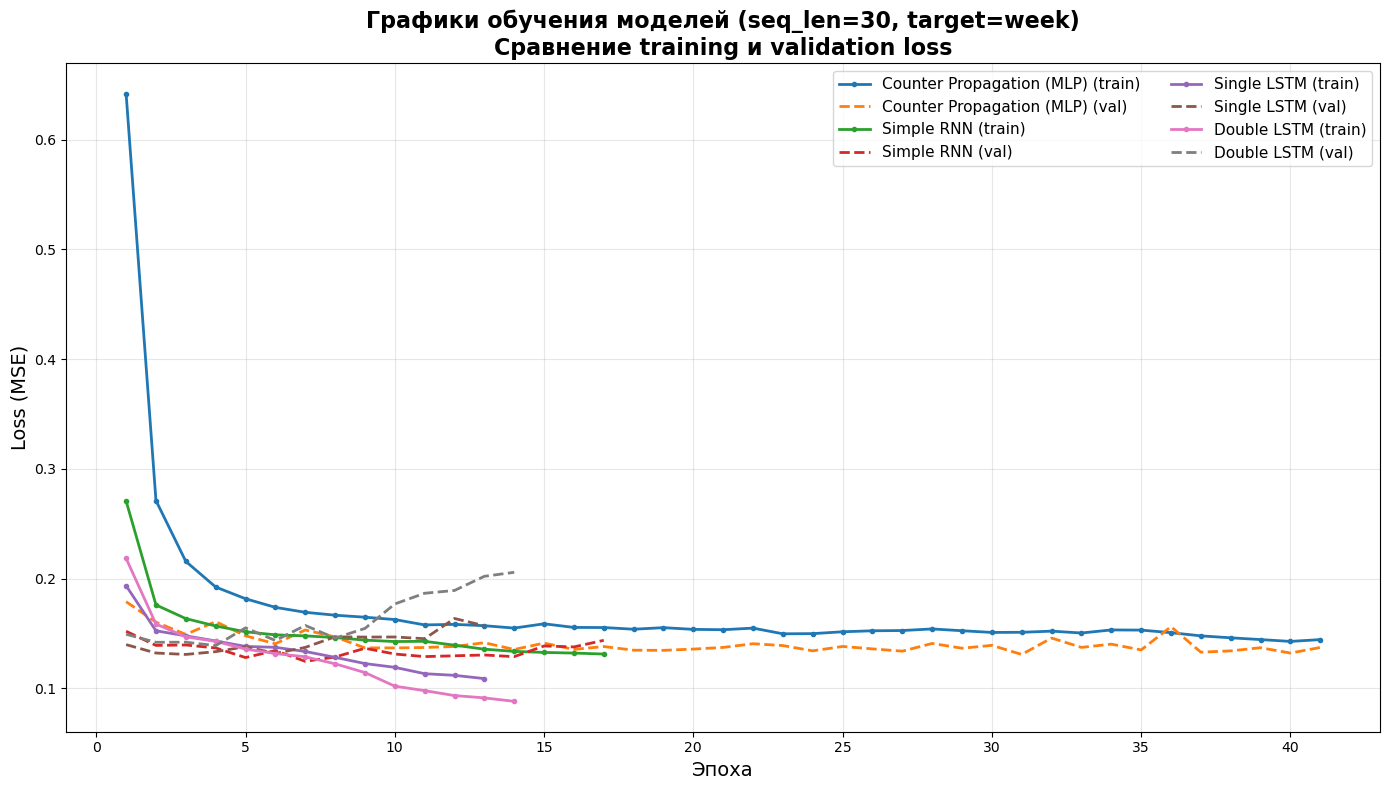

In [84]:
model_names = {
    'counter': 'Counter Propagation (MLP)',
    'rnn': 'Simple RNN',
    'lstm': 'Single LSTM',
    'double_lstm': 'Double LSTM'
}

plt.figure(figsize=(14, 8))

for model_type, hist in history.items():
    train_loss = hist.history['loss']
    val_loss = hist.history['val_loss']
    epochs = range(1, len(train_loss) + 1)
    
    plt.plot(epochs, train_loss, label=f"{model_names[model_type]} (train)", 
             linewidth=2, linestyle='-', marker='o', markersize=3)
    plt.plot(epochs, val_loss, label=f"{model_names[model_type]} (val)", 
             linewidth=2, linestyle='--')

plt.title('Графики обучения моделей (seq_len=30, target=week)\n'
          'Сравнение training и validation loss', fontsize=16, fontweight='bold')
plt.xlabel('Эпоха', fontsize=14)
plt.ylabel('Loss (MSE)', fontsize=14)
plt.legend(fontsize=11, loc='upper right', ncol=2)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

In [ ]:
results = []
model_names = {'counter': 'Counter Propagation', 'rnn': 'Simple RNN', 
               'lstm': 'LSTM', 'double_lstm': 'Double LSTM'}

In [80]:
for mtype, model in models.items():
    print(f"\nОценка {model_names[mtype]}")
    if mtype == 'counter':
        y_pred = model.predict(X_test_flat).flatten()
    else:
        y_pred = model.predict(X_test).flatten()
    
    mse = mean_squared_error(y_test, y_pred)
    mae = mean_absolute_error(y_test, y_pred)
    r2 = r2_score(y_test, y_pred)
    
    results.append({
        'Модель': model_names[mtype],
        'MSE': mse,
        'MAE': mae,
        'R²': r2
    })
    print(f"MSE: {mse:.4f}, MAE: {mae:.4f}, R²: {r2:.4f}")


Оценка Counter Propagation
164/164 ━━━━━━━━━━━━━━━━━━━━ 0s 597us/step
MSE: 0.1300, MAE: 0.2620, R²: 0.4354

Оценка Simple RNN
164/164 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step
MSE: 0.1229, MAE: 0.2541, R²: 0.4664

Оценка LSTM
164/164 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step
MSE: 0.1266, MAE: 0.2553, R²: 0.4504

Оценка Double LSTM
164/164 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step
MSE: 0.1334, MAE: 0.2618, R²: 0.4206


In [81]:
df_results = pd.DataFrame(results)
print("\nИтоговые результаты:")
print(df_results)


Итоговые результаты:
                Модель       MSE       MAE        R²
0  Counter Propagation  0.130045  0.261960  0.435382
1           Simple RNN  0.122893  0.254068  0.466432
2                 LSTM  0.126592  0.255337  0.450372
3          Double LSTM  0.133450  0.261842  0.420599


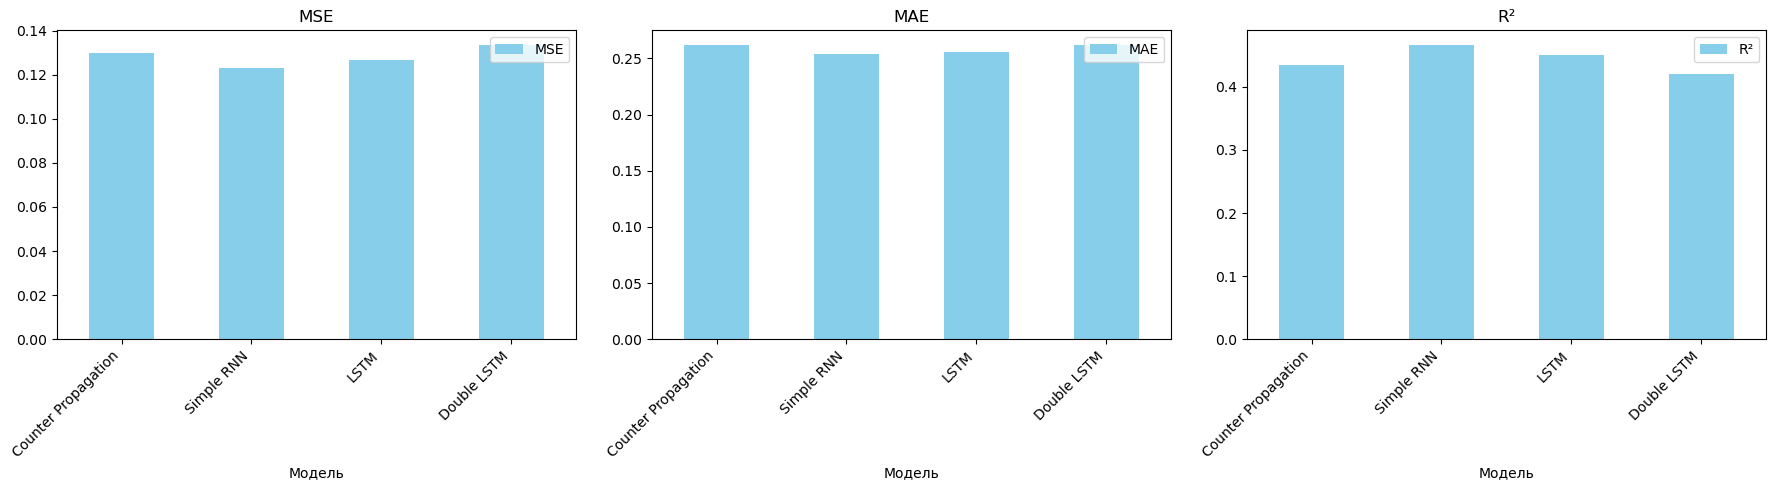

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
metrics = ['MSE', 'MAE', 'R²']
for i, metric in enumerate(metrics):
    ax = axes[i]
    df_results.plot(x='Модель', y=metric, kind='bar', ax=ax, color='skyblue')
    ax.set_title(metric)
    ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right')
plt.tight_layout()
plt.show()

164/164 ━━━━━━━━━━━━━━━━━━━━ 0s 519us/step
164/164 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step
164/164 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step
164/164 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step


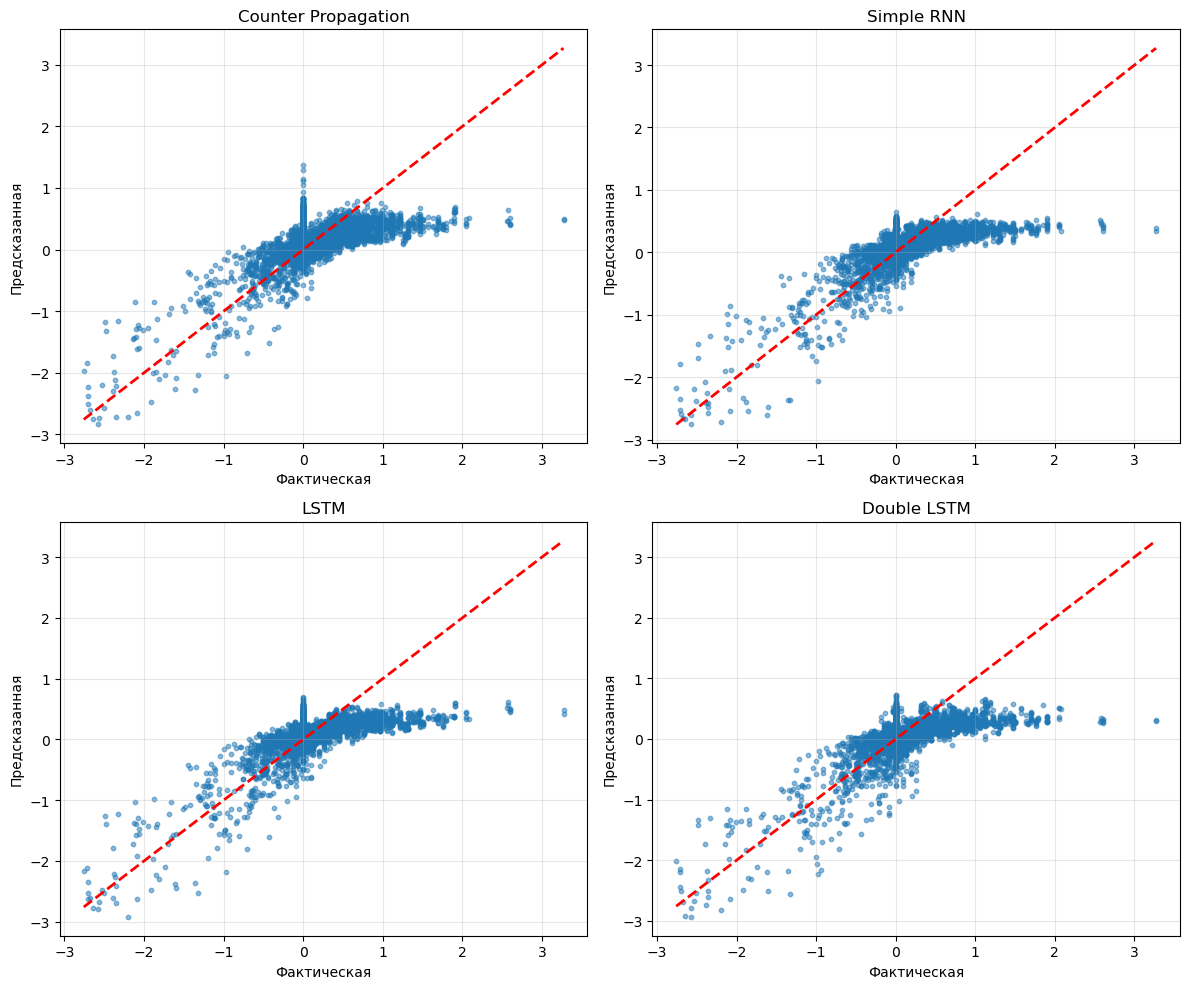

In [ ]:
fig, axes = plt.subplots(2, 2, figsize=(12, 10))
axes = axes.flatten()
for i, (mtype, model) in enumerate(models.items()):
    if mtype == 'counter':
        y_pred = model.predict(X_test_flat).flatten()
    else:
        y_pred = model.predict(X_test).flatten()
    
    ax = axes[i]
    ax.scatter(y_test, y_pred, alpha=0.5, s=10)
    ax.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2)
    ax.set_title(model_names[mtype])
    ax.set_xlabel('Фактическая')
    ax.set_ylabel('Предсказанная')
    ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

In [ ]:

model_names = {
    'counter': 'Counter Propagation (MLP)',
    'rnn': 'Simple RNN',
    'lstm': 'Single LSTM',
    'double_lstm': 'Double LSTM'
}

for model_type, model in models.items():
    print(f"\n{model_names[model_type]}")
    print("-" * 60)
    
    model.summary()
    
    total_params = model.count_params()
    trainable_params = sum([np.prod(v.shape) for v in model.trainable_weights])
    non_trainable_params = sum([np.prod(v.shape) for v in model.non_trainable_weights])
    
    print(f"Всего параметров:        {total_params:,}")
    print(f"Обучаемых параметров:    {trainable_params:,}")
    print(f"Необучаемых параметров:  {non_trainable_params:,}")
    print("-" * 60)


Counter Propagation (MLP)
------------------------------------------------------------


Model: "sequential_91"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ dense_207 (Dense)                    │ (None, 64)                  │          17,344 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_76 (Dropout)                 │ (None, 64)                  │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_77 (Dropout)                 │ (None, 64)                  │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_208 (Dense)                    │ (None, 32)                  │           2,080 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_78 (Dropout)                 │ (None, 32)                  │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_209 (Dense)                    │ (None, 1)                   │              33 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 58,373 (228.02 KB)

 Trainable params: 19,457 (76.00 KB)

...

 Total params: 97,349 (380.27 KB)

 Trainable params: 32,449 (126.75 KB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 64,900 (253.52 KB)

Всего параметров:        32,449
Обучаемых параметров:    32,449
Необучаемых параметров:  0
------------------------------------------------------------
